<a href="https://colab.research.google.com/github/KerimjanKSTU/About_me/blob/main/Practical_2_EDA_Level_Bayel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical Work 2 — Exploratory Data Analysis
## Level B
Dataset: category_performance_summary.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
file_path = "/content/category_performance_summary.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully
Shape: (19, 15)


,category_name,video_count,unique_videos,total_views,avg_views,median_views,avg_likes,avg_dislikes,avg_comments,avg_like_ratio,avg_like_dislike_ratio,avg_days_to_trend,pct_share,like_ratio_pct,like_dislike_pct
0,Entertainment,64543,25471,88284916413,1.367846e+06,333565.0,36036.860140,3204.063338,5027.093008,0.027454,0.908110,1.4,32.443776,2.745434,90.810962
1,Music,30187,4298,240308322284,7.960656e+06,1663852.0,208000.290456,8634.962534,17158.435552,0.041810,0.957177,4.8,15.174074,4.181019,95.717741
2,People & Blogs,18853,8186,17457424991,9.259760e+05,232154.0,27131.787991,2012.614014,3813.212857,0.033432,0.911637,1.3,9.476822,3.343162,91.163719
3,News & Politics,16047,7940,7337708822,4.572636e+05,162701.0,6944.944663,1017.737272,1977.721132,0.016722,0.837162,1.3,8.066332,1.672164,83.716195
4,Comedy,15021,4474,17317757360,1.152903e+06,588664.0,53569.515145,1782.024898,5429.872246,0.047671,0.953131,1.6,7.550594,4.767123,95.313094


## 1. General Dataset Inspection

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
for column in df.columns:
    print("-", column)

print("\nData types:")
print(df.dtypes)

Rows: 19
Columns: 15

Column names:
- category_name
- video_count
- unique_videos
- total_views
- avg_views
- median_views
- avg_likes
- avg_dislikes
- avg_comments
- avg_like_ratio
- avg_like_dislike_ratio
- avg_days_to_trend
- pct_share
- like_ratio_pct
- like_dislike_pct

Data types:
category_name              object
video_count                 int64
unique_videos               int64
total_views                 int64
avg_views                 float64
median_views              float64
avg_likes                 float64
avg_dislikes              float64
avg_comments              float64
avg_like_ratio            float64
avg_like_dislike_ratio    float64
avg_days_to_trend         float64
pct_share                 float64
like_ratio_pct            float64
like_dislike_pct          float64
dtype: object


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   category_name           19 non-null     object 
 1   video_count             19 non-null     int64  
 2   unique_videos           19 non-null     int64  
 3   total_views             19 non-null     int64  
 4   avg_views               19 non-null     float64
 5   median_views            19 non-null     float64
 6   avg_likes               19 non-null     float64
 7   avg_dislikes            19 non-null     float64
 8   avg_comments            19 non-null     float64
 9   avg_like_ratio          19 non-null     float64
 10  avg_like_dislike_ratio  19 non-null     float64
 11  avg_days_to_trend       19 non-null     float64
 12  pct_share               19 non-null     float64
 13  like_ratio_pct          19 non-null     float64
 14  like_dislike_pct        19 non-null     floa

In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
category_name             0
video_count               0
unique_videos             0
total_views               0
avg_views                 0
median_views              0
avg_likes                 0
avg_dislikes              0
avg_comments              0
avg_like_ratio            0
avg_like_dislike_ratio    0
avg_days_to_trend         0
pct_share                 0
like_ratio_pct            0
like_dislike_pct          0
dtype: int64

Total missing values:
0

Duplicate rows:
0


### Feature Classification

In [6]:
categorical_cols = [
    "category_name"
]

discrete_numeric_cols = [
    "video_count",
    "unique_videos",
    "total_views"
]

continuous_numeric_cols = [
    "avg_views",
    "median_views",
    "avg_likes",
    "avg_dislikes",
    "avg_comments",
    "avg_like_ratio",
    "avg_like_dislike_ratio",
    "avg_days_to_trend",
    "pct_share",
    "like_ratio_pct",
    "like_dislike_pct"
]

print("Categorical features:")
print(categorical_cols)

print("\nDiscrete numerical features:")
print(discrete_numeric_cols)

print("\nContinuous numerical features:")
print(continuous_numeric_cols)

Categorical features:
['category_name']

Discrete numerical features:
['video_count', 'unique_videos', 'total_views']

Continuous numerical features:
['avg_views', 'median_views', 'avg_likes', 'avg_dislikes', 'avg_comments', 'avg_like_ratio', 'avg_like_dislike_ratio', 'avg_days_to_trend', 'pct_share', 'like_ratio_pct', 'like_dislike_pct']


In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns

display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
video_count,19.0,1.047042e+04,1.540512e+04,1.000000,7.820000e+02,5.432000e+03,1.301850e+04,6.454300e+04
unique_videos,19.0,3.650684e+03,5.856755e+03,1.000000,3.235000e+02,1.909000e+03,4.363000e+03,2.547100e+04
total_views,19.0,2.304679e+10,5.630479e+10,8804.000000,6.374271e+08,6.073449e+09,1.568987e+10,2.403083e+11
avg_views,19.0,1.521646e+06,1.742827e+06,8804.000000,6.475861e+05,1.088432e+06,1.383832e+06,7.960656e+06
median_views,19.0,4.816164e+05,5.645243e+05,8804.000000,2.069928e+05,3.097900e+05,5.352890e+05,2.289027e+06
avg_likes,19.0,5.134698e+04,6.832857e+04,0.000000,1.518960e+04,2.932814e+04,4.336035e+04,2.599236e+05
avg_dislikes,19.0,5.898201e+03,1.361254e+04,0.000000,7.753726e+02,1.782025e+03,2.510419e+03,5.807686e+04
avg_comments,19.0,9.646258e+03,1.925732e+04,0.000000,2.117381e+03,3.813213e+03,5.931807e+03,8.436486e+04
avg_like_ratio,19.0,3.191831e-02,1.382927e-02,0.000000,2.309157e-02,3.343162e-02,4.322375e-02,4.778079e-02
avg_like_dislike_ratio,19.0,9.286570e-01,4.492518e-02,0.804568,9.157406e-01,9.439273e-01,9.535930e-01,1.000000e+00


In [8]:
skewness = df[numeric_cols].skew().sort_values(ascending=False)

print("Skewness:")
display(skewness.to_frame("skewness"))

Skewness:


,skewness
avg_comments,3.641630
total_views,3.623417
avg_dislikes,3.569577
avg_days_to_trend,3.528717
unique_videos,3.163432
avg_views,3.092936
video_count,2.696426
pct_share,2.696426
median_views,2.483674
avg_likes,2.422437


## 2. Numerical Feature Distributions

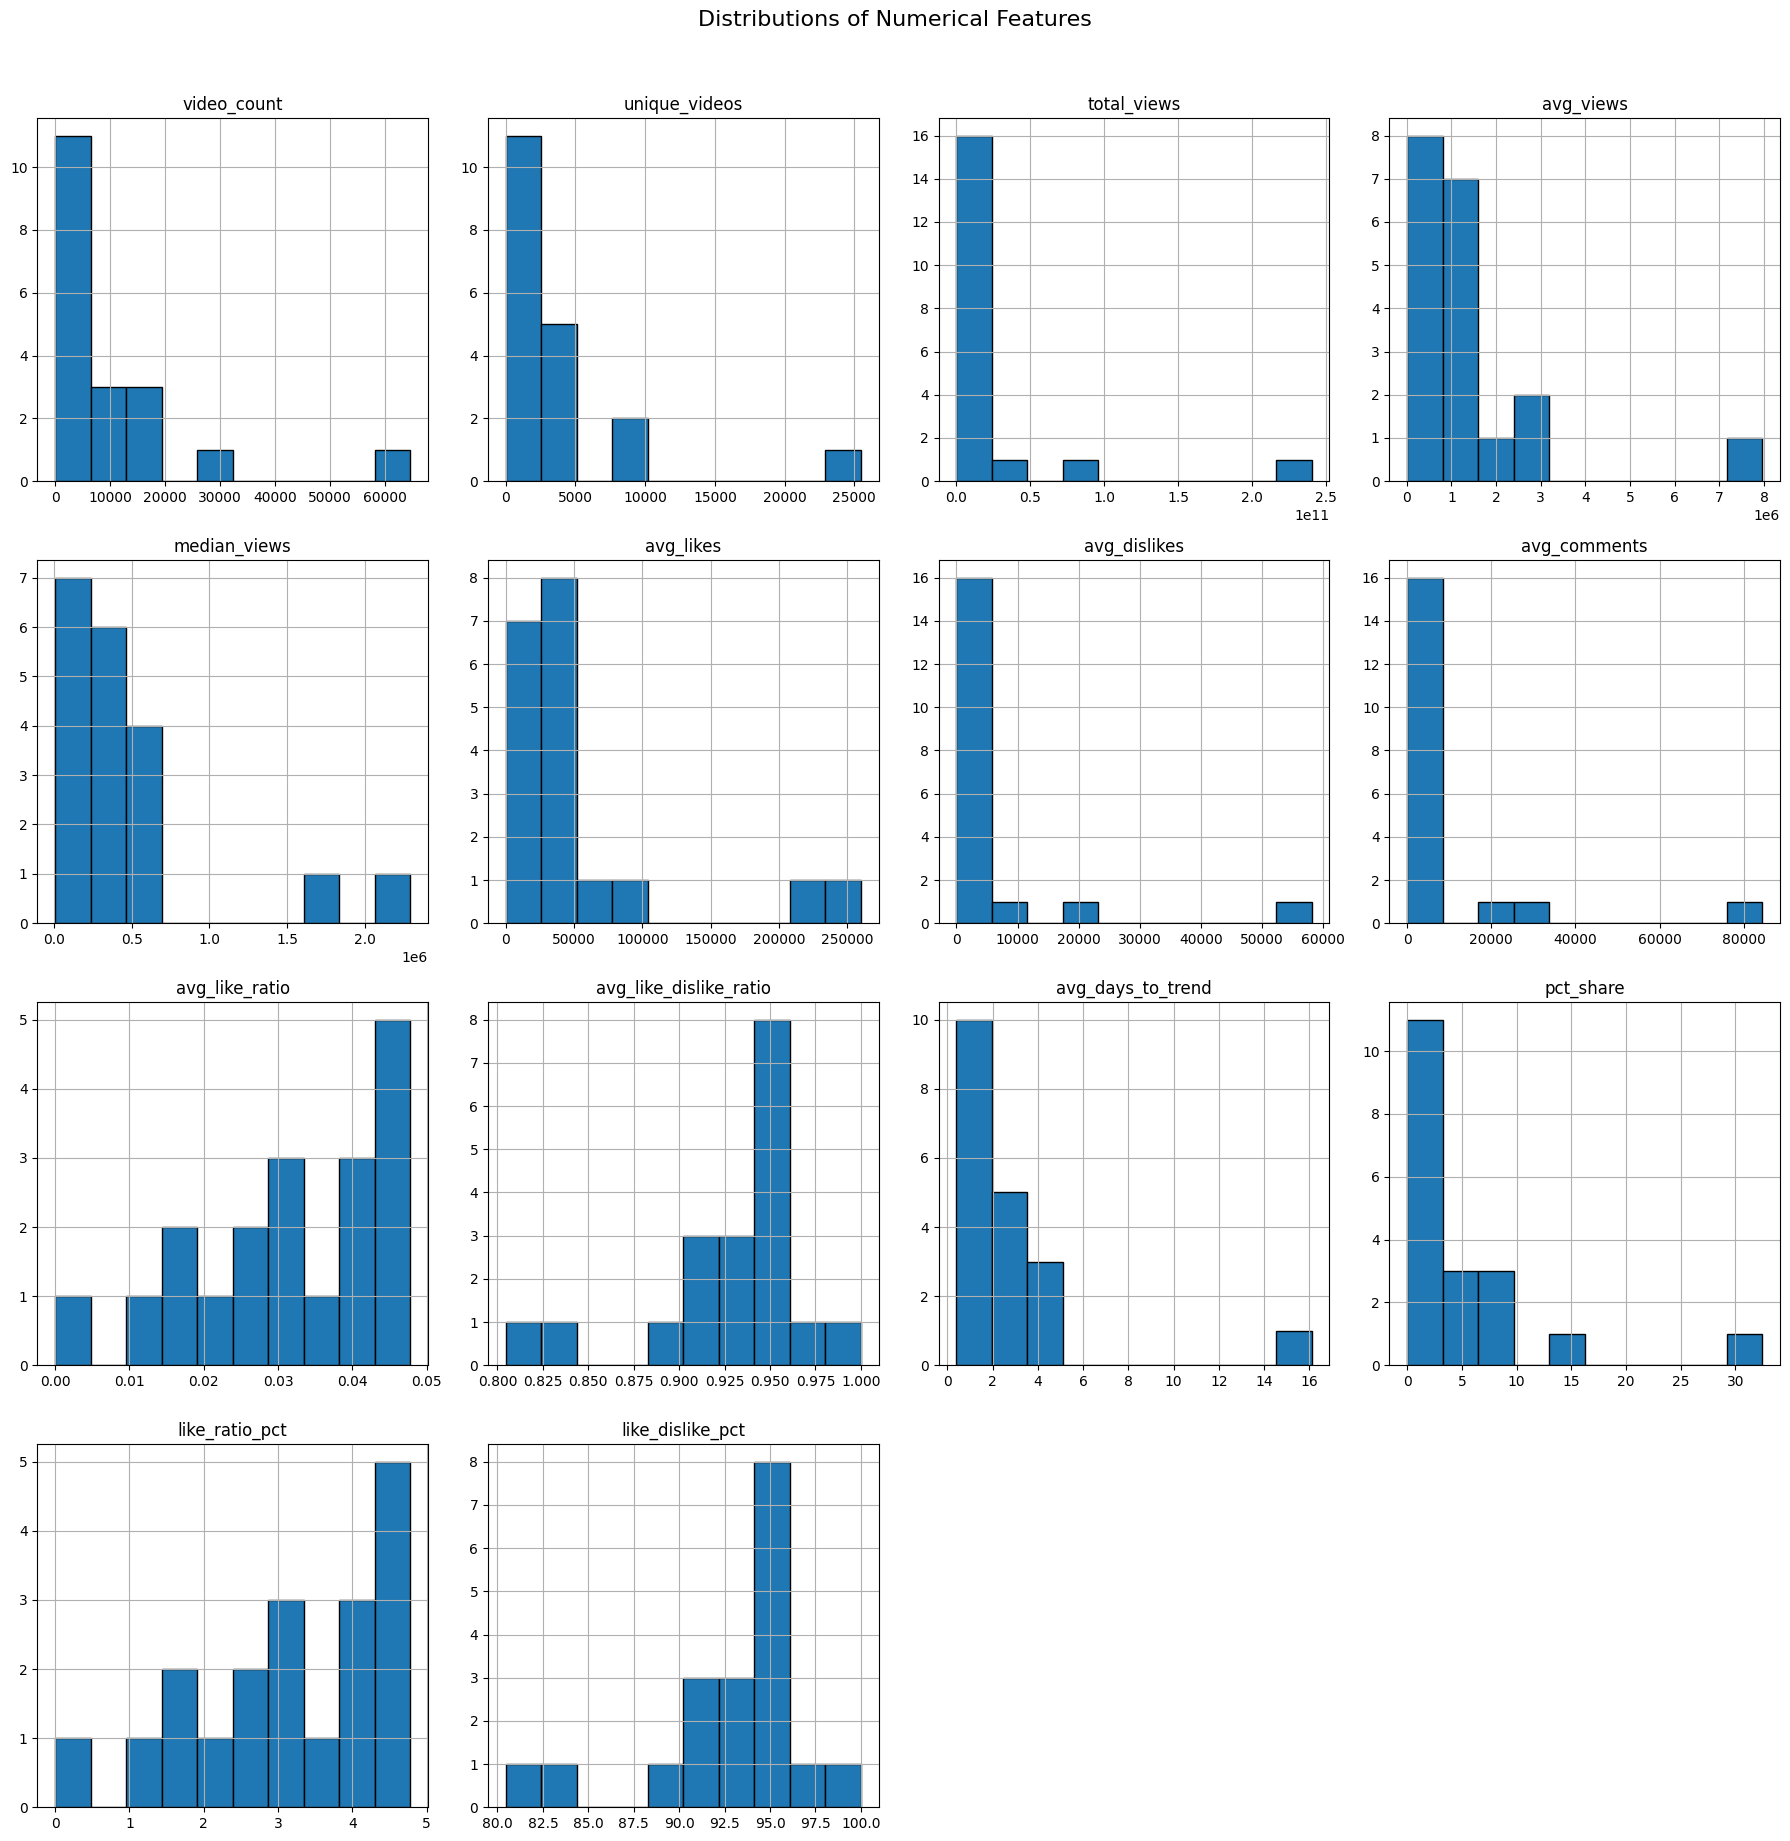

In [9]:
df[numeric_cols].hist(
    bins=10,
    figsize=(18, 18),
    edgecolor="black"
)

plt.suptitle(
    "Distributions of Numerical Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

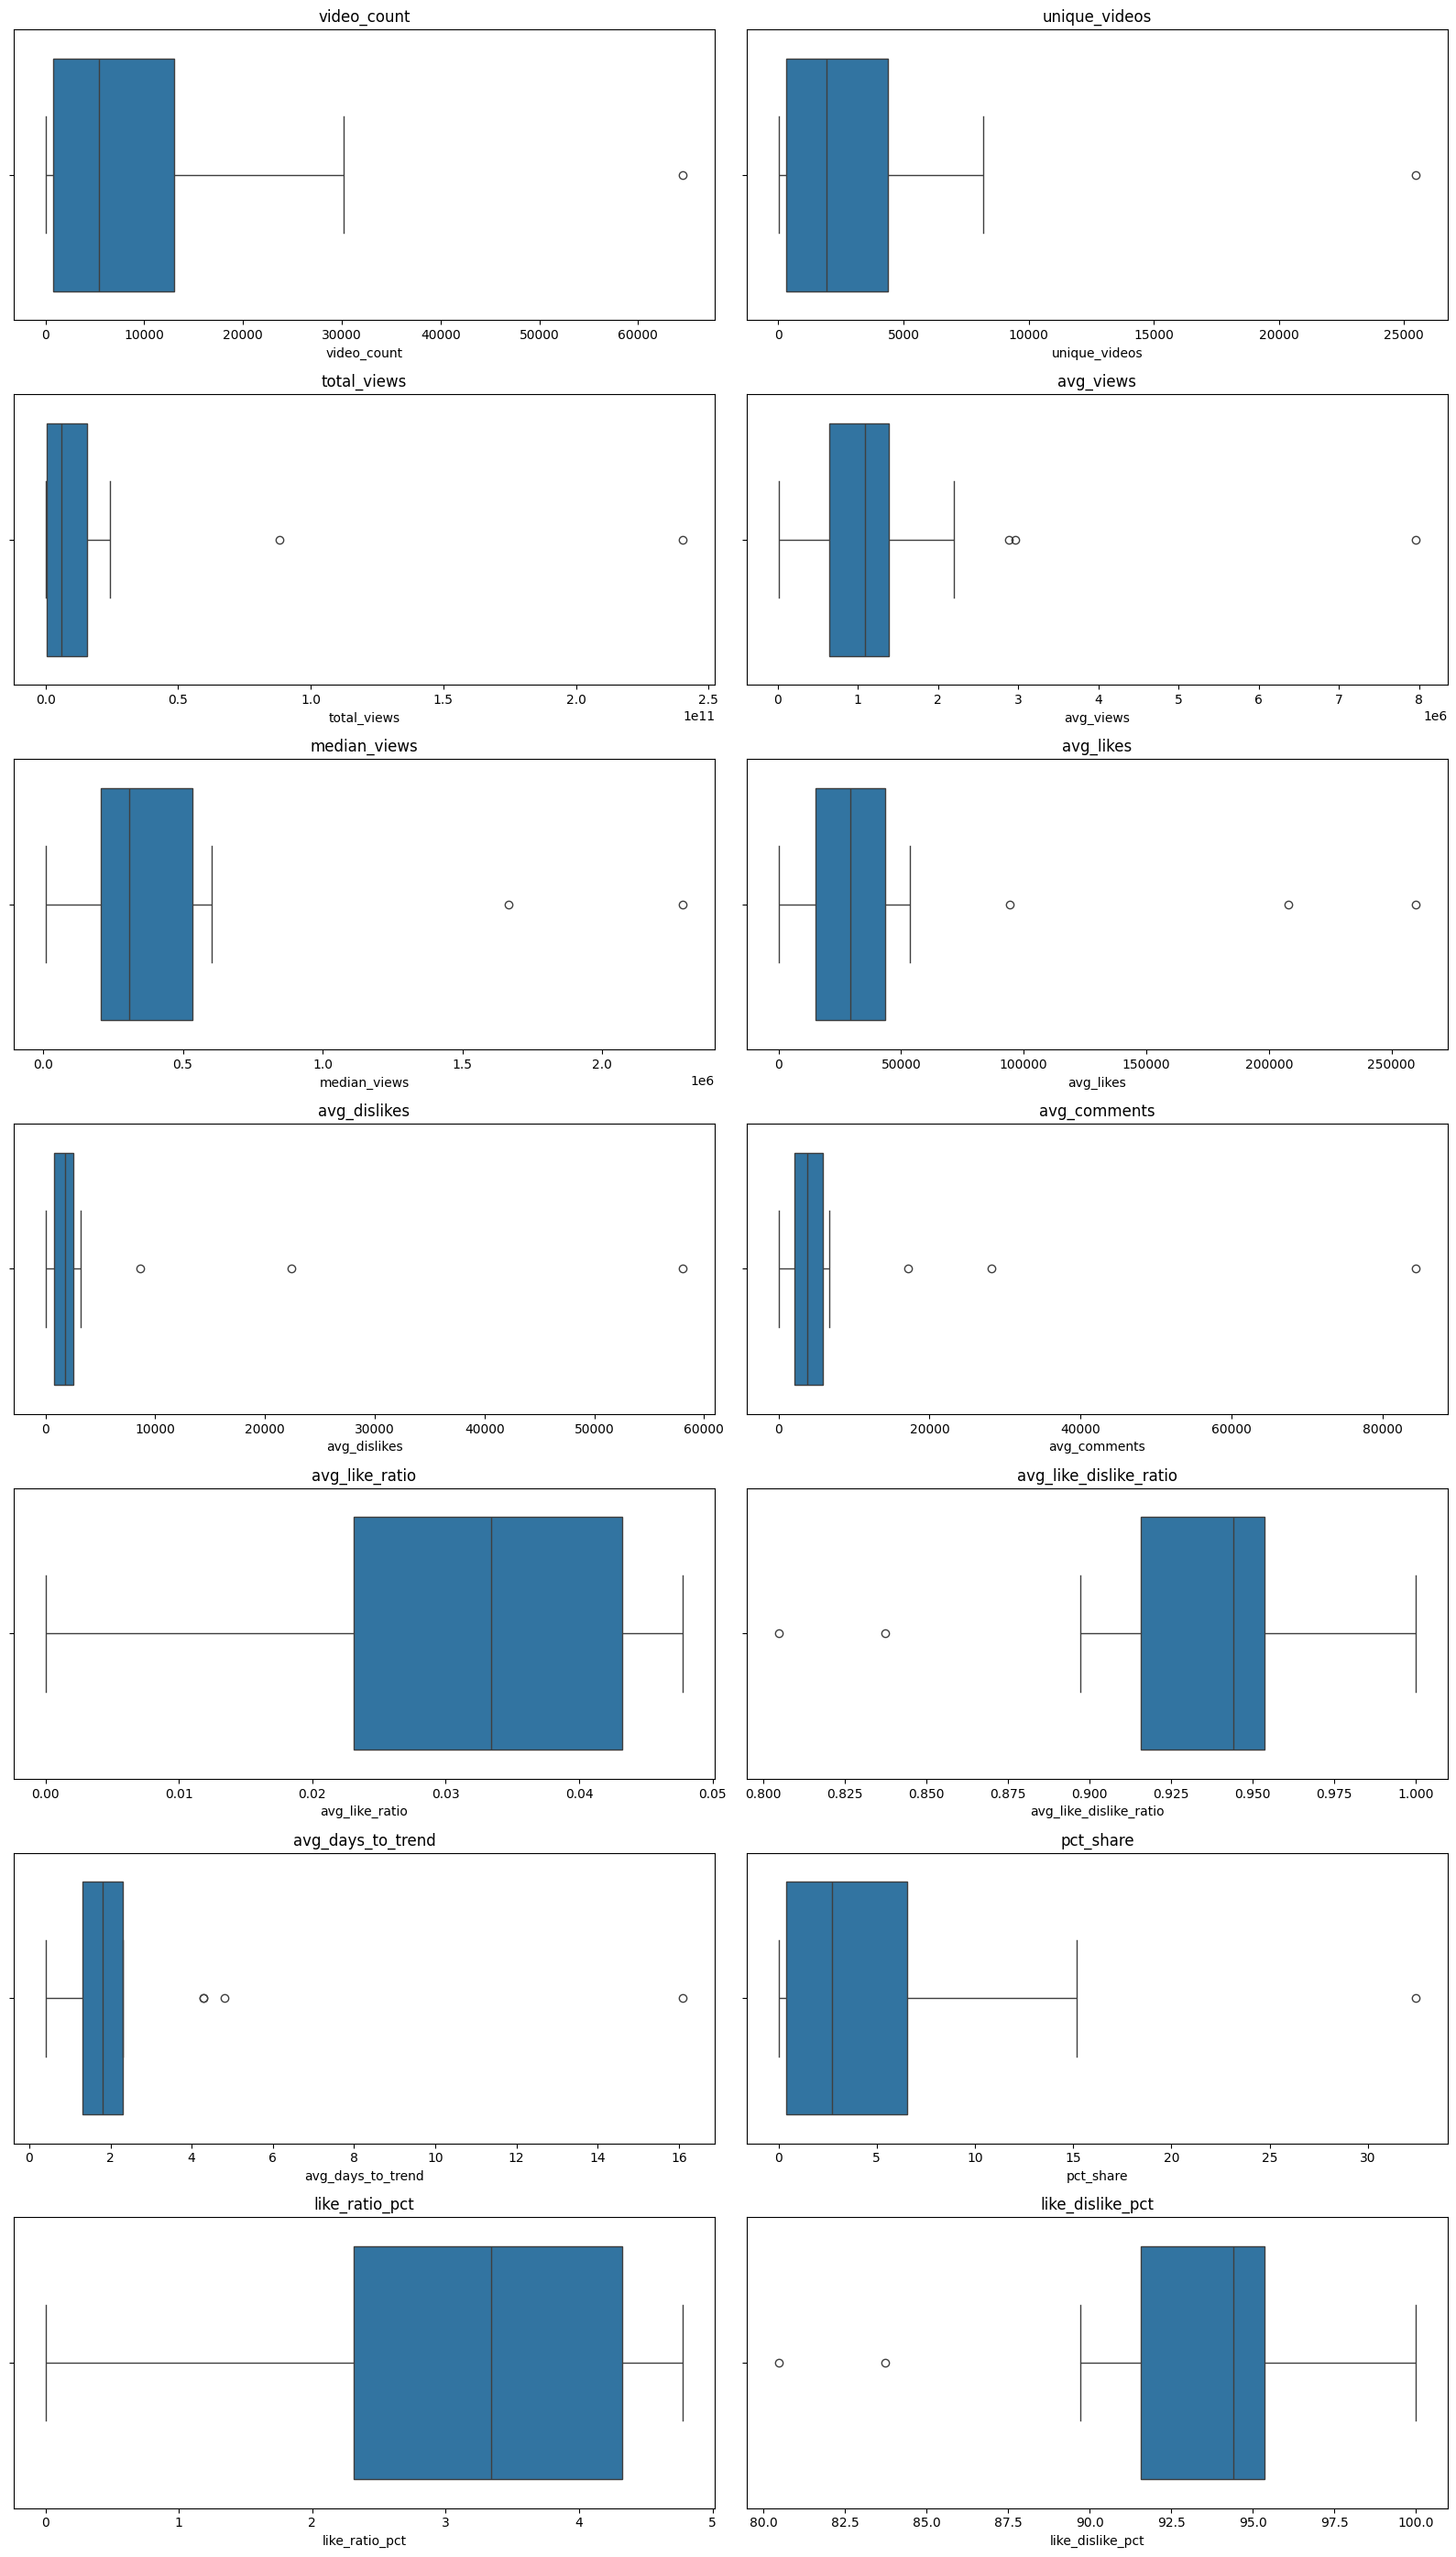

In [10]:
n_cols = 2
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for i in range(len(numeric_cols), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [11]:
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        "feature": col,
        "outlier_count": len(outliers),
        "outlier_categories": ", ".join(outliers["category_name"].tolist())
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)

,feature,outlier_count,outlier_categories
0,video_count,1,Entertainment
1,unique_videos,1,Entertainment
2,total_views,2,"Entertainment, Music"
3,avg_views,3,"Music, Nonprofits & Activism, Movies"
4,median_views,2,"Music, Movies"
5,avg_likes,3,"Music, Unknown / Other, Nonprofits & Activism"
6,avg_dislikes,3,"Music, Unknown / Other, Nonprofits & Activism"
7,avg_comments,3,"Music, Unknown / Other, Nonprofits & Activism"
8,avg_like_ratio,0,
9,avg_like_dislike_ratio,2,"News & Politics, Shows"


## 3. Categorical Feature Analysis

In [12]:
category_frequency = df["category_name"].value_counts()

display(category_frequency)

print(
    "Number of unique categories:",
    df["category_name"].nunique()
)

,count
category_name,
Entertainment,1
Music,1
People & Blogs,1
News & Politics,1
Comedy,1
Film & Animation,1
Howto & Style,1
Sports,1
Gaming,1


Number of unique categories: 19


In [13]:
rare_categories = (
    df.loc[
        df["pct_share"] < 1,
        ["category_name", "video_count", "pct_share"]
    ]
    .sort_values("pct_share")
)

display(rare_categories)

,category_name,video_count,pct_share
18,Trailers,1,0.000503
17,Movies,24,0.012064
16,Nonprofits & Activism,57,0.028652
15,Shows,513,0.257869
14,Unknown / Other,525,0.263901
13,Travel & Events,1039,0.522273
12,Autos & Vehicles,1826,0.917874


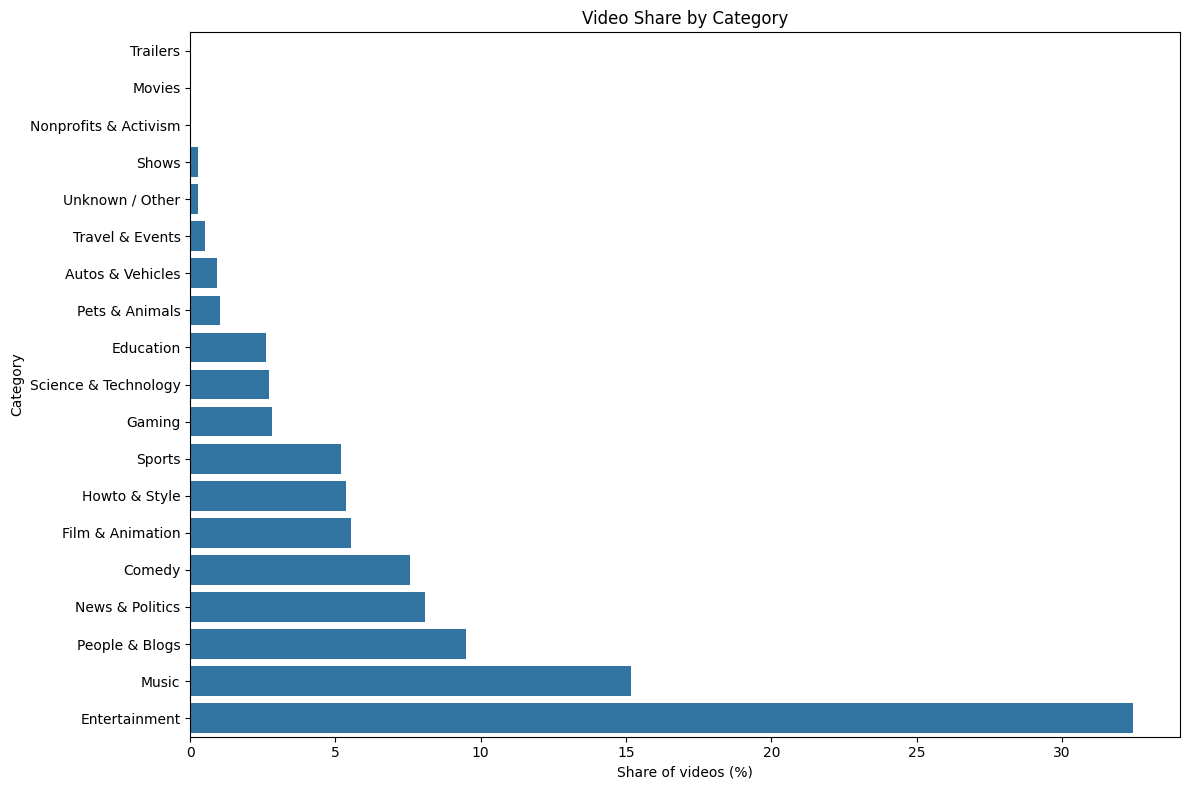

In [14]:
category_share = df.sort_values(
    "pct_share",
    ascending=True
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=category_share,
    x="pct_share",
    y="category_name"
)

plt.xlabel("Share of videos (%)")
plt.ylabel("Category")
plt.title("Video Share by Category")

plt.tight_layout()
plt.show()

## 4. Correlation Analysis

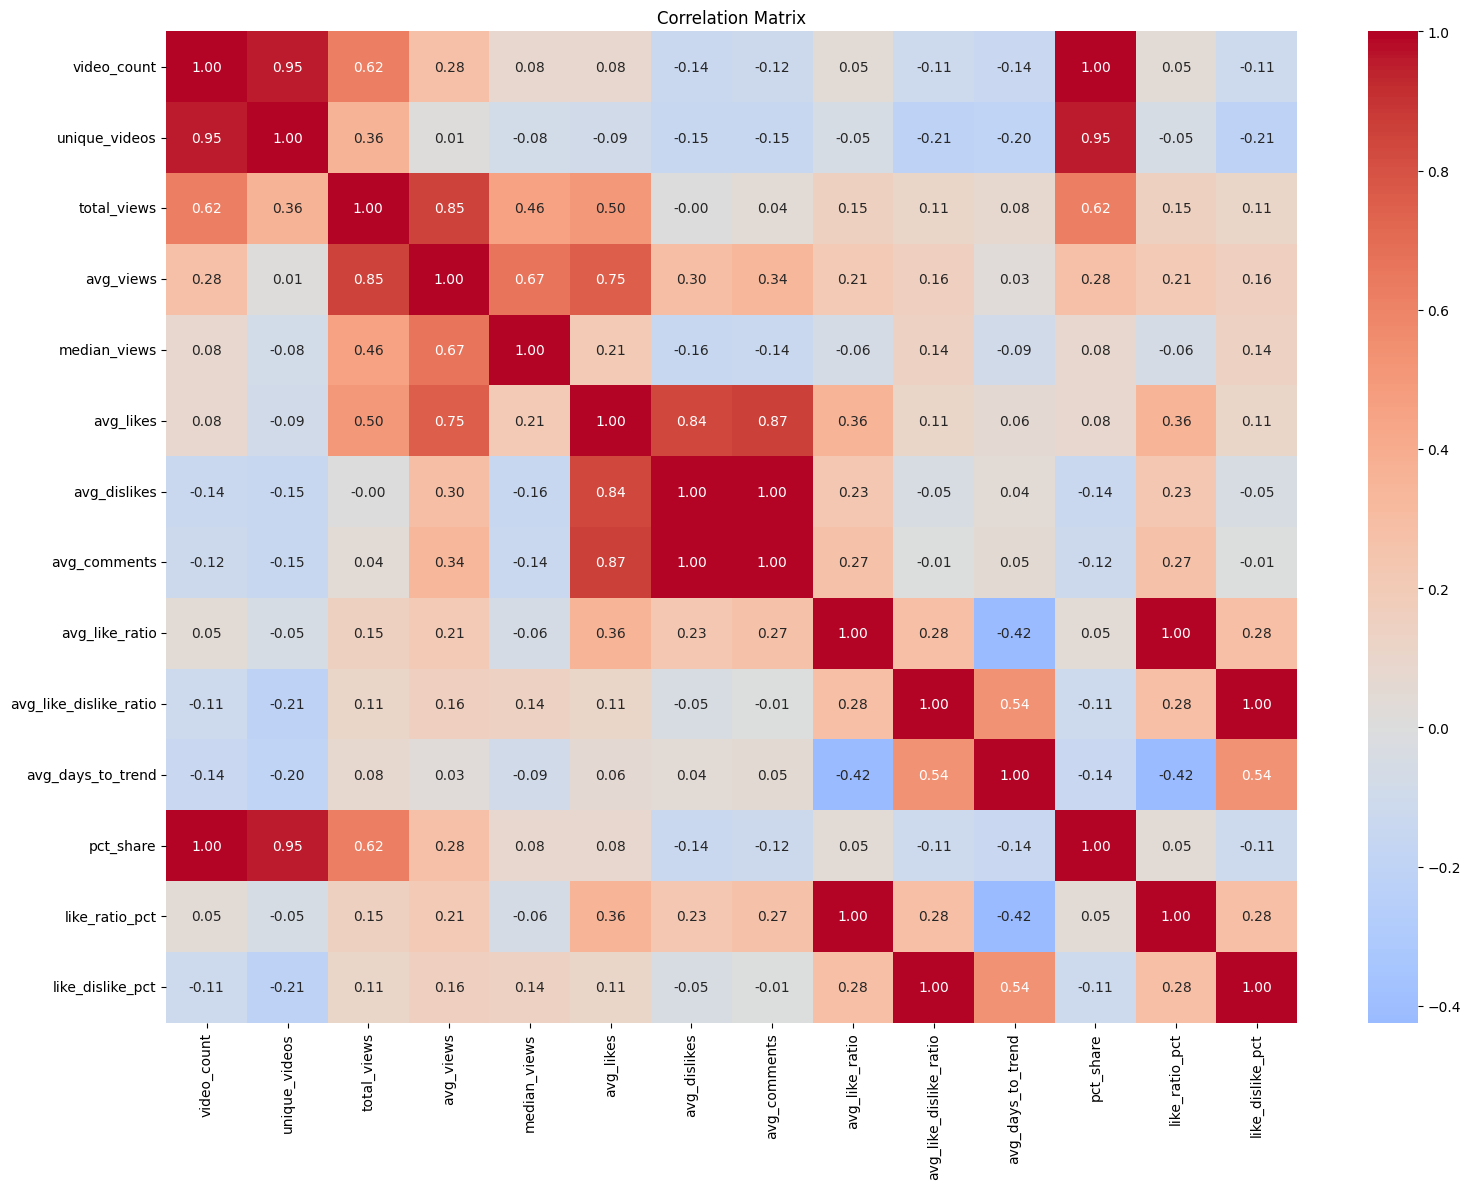

In [15]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [16]:
upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

strongest_correlations = (
    upper_triangle
    .stack()
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

display(
    strongest_correlations
    .head(15)
    .to_frame("correlation")
)

,,correlation
avg_like_dislike_ratio,like_dislike_pct,1.000000
avg_like_ratio,like_ratio_pct,1.000000
video_count,pct_share,1.000000
avg_dislikes,avg_comments,0.995205
unique_videos,pct_share,0.952588
video_count,unique_videos,0.952588
avg_likes,avg_comments,0.866259
total_views,avg_views,0.853709
avg_likes,avg_dislikes,0.836864
avg_views,avg_likes,0.752540


In [17]:
print(
    "like_ratio_pct = avg_like_ratio * 100:",
    np.allclose(
        df["like_ratio_pct"],
        df["avg_like_ratio"] * 100
    )
)

print(
    "like_dislike_pct = avg_like_dislike_ratio * 100:",
    np.allclose(
        df["like_dislike_pct"],
        df["avg_like_dislike_ratio"] * 100
    )
)

print(
    "pct_share derived from video_count:",
    np.allclose(
        df["pct_share"],
        df["video_count"] / df["video_count"].sum() * 100
    )
)

print(
    "Total pct_share:",
    df["pct_share"].sum()
)

like_ratio_pct = avg_like_ratio * 100: True
like_dislike_pct = avg_like_dislike_ratio * 100: True
pct_share derived from video_count: True
Total pct_share: 100.0


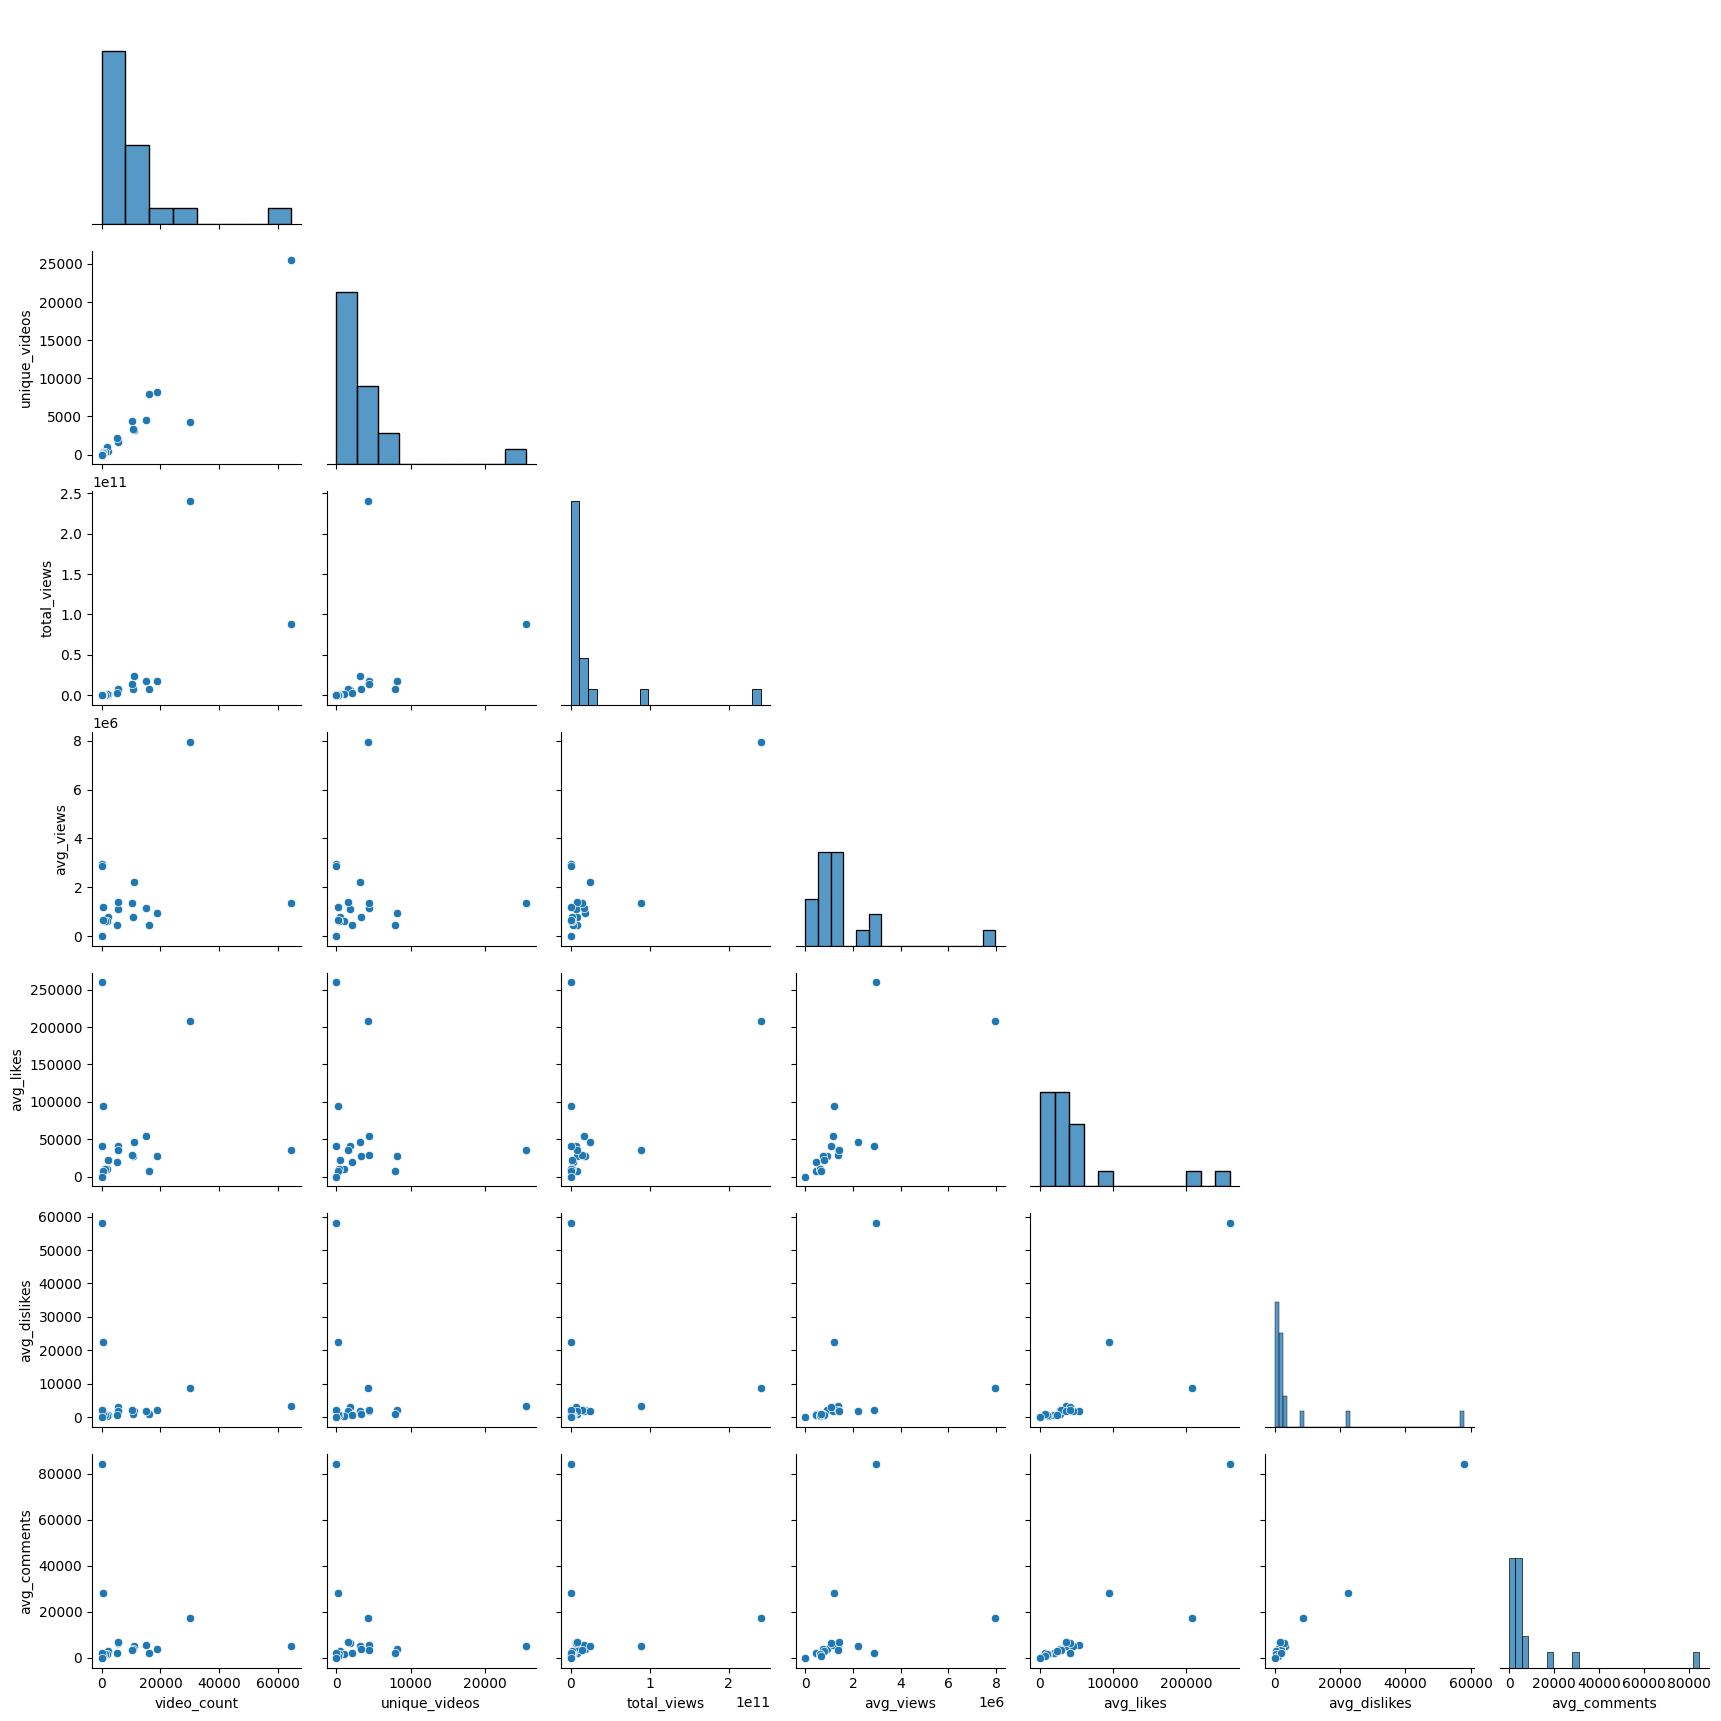

In [18]:
scatter_features = [
    "video_count",
    "unique_videos",
    "total_views",
    "avg_views",
    "avg_likes",
    "avg_dislikes",
    "avg_comments"
]

sns.pairplot(
    df[scatter_features],
    corner=True,
    diag_kind="hist"
)

plt.show()

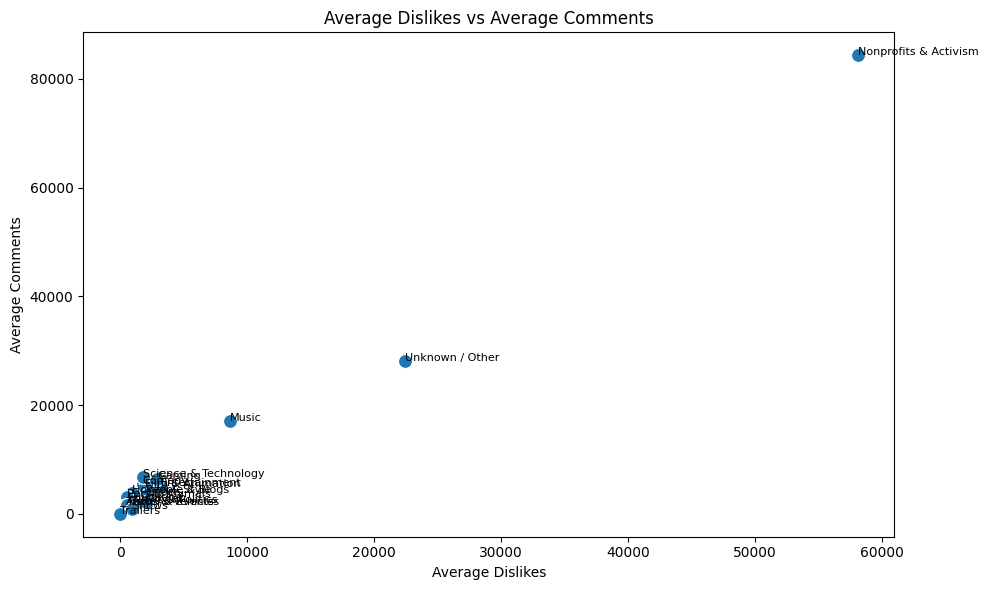

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="avg_dislikes",
    y="avg_comments",
    s=100
)

for _, row in df.iterrows():
    plt.annotate(
        row["category_name"],
        (row["avg_dislikes"], row["avg_comments"]),
        fontsize=8
    )

plt.title(
    "Average Dislikes vs Average Comments"
)

plt.xlabel("Average Dislikes")
plt.ylabel("Average Comments")

plt.tight_layout()
plt.show()

## 5. Target Variable and Class Imbalance

The dataset does not contain an explicitly defined target variable for a
classification task. `category_name` is an identifier/category dimension,
and every category appears exactly once because the dataset is already
aggregated by category.

Therefore, class imbalance analysis is not applicable to this dataset.

In [20]:
zero_counts = (df[numeric_cols] == 0).sum()

display(
    zero_counts[
        zero_counts > 0
    ].sort_values(ascending=False)
)

,0
avg_likes,1
avg_dislikes,1
avg_comments,1
avg_like_ratio,1
like_ratio_pct,1


## 6. EDA Summary

In [21]:
print("===== FINAL DATASET SUMMARY =====")

print("Rows:", len(df))
print("Columns:", len(df.columns))

print(
    "Numerical features:",
    len(numeric_cols)
)

print(
    "Categorical features:",
    len(categorical_cols)
)

print(
    "Missing values:",
    df.isnull().sum().sum()
)

print(
    "Duplicate rows:",
    df.duplicated().sum()
)

print(
    "Unique categories:",
    df["category_name"].nunique()
)

print(
    "Categories with <1% share:",
    (df["pct_share"] < 1).sum()
)

print(
    "Classification target:",
    "Not defined"
)

===== FINAL DATASET SUMMARY =====
Rows: 19
Columns: 15
Numerical features: 14
Categorical features: 1
Missing values: 0
Duplicate rows: 0
Unique categories: 19
Categories with <1% share: 7
Classification target: Not defined


### Conclusions and Identified Data Quality Issues

1. The dataset contains 19 observations and 15 features: one categorical feature (`category_name`) and 14 numerical features. No missing values or fully duplicated rows were detected, so missing-value imputation and duplicate removal are not required at this stage.

2. A large proportion of the numerical variables have strongly right-skewed distributions. In particular, `avg_comments`, `total_views`, `avg_dislikes`, `avg_days_to_trend`, `unique_videos`, and `avg_views` have high positive skewness. On the next stage, logarithmic transformations such as `log1p()` may be considered before modelling or statistical analysis.

3. The IQR method detected several potential outliers. `Entertainment`, `Music`, `Nonprofits & Activism`, `Movies`, `Unknown / Other`, and `Trailers` are responsible for many extreme values. These observations should not be removed automatically because they may represent genuine differences between YouTube categories. Their validity should be checked before applying transformations or robust scaling.

4. The dataset is highly imbalanced in terms of category representation in the original videos. Using a threshold of less than 1% of all videos, seven low-volume categories were identified: `Trailers`, `Movies`, `Nonprofits & Activism`, `Shows`, `Unknown / Other`, `Travel & Events`, and `Autos & Vehicles`. If the data are later used for predictive modelling, these low-volume categories may require special treatment or combination, depending on the modelling objective.

5. Several numerical features contain redundant information. `like_ratio_pct` is equal to `avg_like_ratio × 100`, `like_dislike_pct` is equal to `avg_like_dislike_ratio × 100`, and `pct_share` is derived directly from `video_count`. Therefore, these feature pairs show correlations of approximately 1.0. Before modelling, redundant columns should be removed to reduce multicollinearity and unnecessary feature duplication.

6. Strong positive relationships were also observed between non-identical variables. In particular, `avg_dislikes` and `avg_comments` have a correlation of approximately 0.995, `video_count` and `unique_videos` approximately 0.953, `avg_likes` and `avg_comments` approximately 0.866, and `total_views` and `avg_views` approximately 0.854. Some of these correlations may be strongly affected by extreme categories, so they should be re-evaluated after transformations and with robust or rank-based correlation methods.

7. The dataset does not contain an explicitly defined classification target. `category_name` represents the aggregation dimension and occurs exactly once per row. Therefore, class-imbalance analysis is not applicable to the current dataset. If a predictive task is introduced later, the target variable must first be explicitly defined. Because the current dataset contains only 19 aggregated observations, predictive modelling should preferably use the original video-level dataset rather than this category-level summary.
